In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import welch
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# Análisis y limpieza de datos

In [2]:
# Cargargo los datos desde un archivo CSV
df = pd.read_csv('Heart_Rate_VR_Data.csv')
df.head(15)

,user,sex,VR experience,heart/vertigo issue,time,event,fear level,hear rate file
0,ignacio,1,1,0,0:00,relax,0,ignacio.txt
1,ignacio,1,1,0,0:56,VR on,0,ignacio.txt
2,ignacio,1,1,0,1:46,going up in the elevator,0,ignacio.txt
3,ignacio,1,1,0,2:03,open elevator doors,0,ignacio.txt
4,ignacio,1,1,0,2:31,start walk,3,ignacio.txt
5,ignacio,1,1,0,3:24,end walk,3,ignacio.txt
6,ignacio,1,1,0,3:25,elevator,0,ignacio.txt
7,ignacio,1,1,0,4:09,start red light,2,ignacio.txt
8,ignacio,1,1,0,5:00,fall,0,ignacio.txt
9,ignacio,1,1,0,5:27,VR off,0,ignacio.txt


In [3]:
# Análisis de valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
user                   0
sex                    0
VR experience          0
heart/vertigo issue    0
time                   0
event                  0
fear level             0
hear rate file         0
dtype: int64


In [4]:
# Verifico los valores únicos registrados
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Valores únicos en la columna '{column}':")
    print(unique_values)
    print() 

Valores únicos en la columna 'user':
['ignacio' 'juan' 'david' 'jorge' 'cristina' 'isabel' 'katia' 'cielo'
 'mario' 'jaime' 'luis']

Valores únicos en la columna 'sex':
[1 0]

Valores únicos en la columna 'VR experience':
[1 0]

Valores únicos en la columna 'heart/vertigo issue':
[0 1]

Valores únicos en la columna 'time':
['0:00' '0:56' '1:46' '2:03' '2:31' '3:24' '3:25' '4:09' '5:00' '5:27'
 '1:12' '2:09' '2:26' '3:07' '3:28' '3:29' '5:28' '6:59' '7:00' '7:38'
 '8:02' '1:28' '2:06' '2:45' '3:04' '4:23' '4:24' '5:09' '5:59' '0:44'
 '1:05' '1:22' '1:42' '2:04' '2:05' '2:43' '3:00' '3:19' '3:22' '3:26'
 '3:58' '4:08' '4:34' '1:23' '1:40' '3:20' '3:42' '6:23' '6:24' '7:26'
 '9:18' '9:40' '1:14' '7:56' '1:06' '1:50' '2:25' '3:27' '4:07' '4:39'
 '5:10' '5:18' '5:45' '1:02' '2:08' '2:22' '2:46' '3:21' '4:06' '4:10'
 '4:26' '4:51' '6:17' '6:18' '6:36' '1:37' '2:14' '2:59' '4:31' '5:24'
 '5:25' '5:52' '6:11' '2:24' '2:42' '2:50' '3:30' '4:18' '4:20' '4:37'
 '5:04' '5:13' '1:04' '2:23' '2:41' 

Reemplazamos 'eleveator' por 'elevator' y eliminamos la entrada incorrecta donde la marca de tiempo no tiene sentido ya que hay otra que es el 0:00 y es el relax:

Mario, 1, 1, 0:00, end walk, 1, mario.txt

In [5]:
df['event'] = df['event'].replace('eleveator', 'elevator')

df = df[~((df['user'] == 'mario') &
           (df['sex'] == 1) &
           (df['VR experience'] == 1) &
           (df['heart/vertigo issue'] == 0) &
           (df['time'] == '0:00') &
           (df['event'] == 'end walk') &
           (df['fear level'] == 1) &
           (df['hear rate file'] == 'mario.txt'))]

df.to_csv('Heart_Rate_VR_Data_Correct.csv', index=False)

In [6]:
df = pd.read_csv('Heart_Rate_VR_Data_Correct.csv')

In [7]:
# Contamos la cantidad de eventos por usuario
eventos_por_usuario = df.groupby('user')['event'].nunique()
print("Número de eventos por usuario:")
print(eventos_por_usuario)

Número de eventos por usuario:
user
cielo       11
cristina    10
david       10
ignacio     10
isabel       6
jaime        9
jorge       10
juan        11
katia       10
luis         9
mario       10
Name: event, dtype: int64


In [8]:
# Se verifican los eventos realizados por cada usuario
eventos_por_usuario = df.groupby('user')['event'].unique()

# Convierto el resultado en un DataFrame
eventos_df = pd.DataFrame(eventos_por_usuario).reset_index()

# Renombro las columnas para mayor claridad
eventos_df.columns = ['Usuarios', 'Eventos Realizados']

print("Eventos realizados por cada usuario:")
print(eventos_df.to_string(index=False))

Eventos realizados por cada usuario:
Usuarios                                                                                                                          Eventos Realizados
   cielo [relax, VR on, going up in the elevator, open elevator doors, start walk, end walk, elevator, start red light, fall, end red light, VR off]
cristina       [relax, VR on, going up in the elevator, open elevator doors, start walk, end walk, elevator, start red light, end red light, VR off]
   david                [relax, VR on, going up in the elevator, open elevator doors, start walk, end walk, elevator, start red light, fall, VR off]
 ignacio                [relax, VR on, going up in the elevator, open elevator doors, start walk, end walk, elevator, start red light, fall, VR off]
  isabel                                                         [relax, VR on, going up in the elevator, open elevator doors, start walk, end walk]
   jaime                        [relax, VR on, going up in the elevat

In [9]:
# Obtener todos los eventos únicos
todos_los_eventos = set(df['event'].dropna().unique())

# Agrupar por usuario y obtener los eventos únicos realizados por cada uno
eventos_por_usuario = df.groupby('user')['event'].unique()

# Crear un diccionario para almacenar los eventos faltantes por usuario
eventos_faltantes_por_usuario = {}

# Calcular los eventos faltantes para cada usuario
for user, eventos in eventos_por_usuario.items():
    eventos_realizados = set(eventos)
    eventos_faltantes = todos_los_eventos - eventos_realizados
    eventos_faltantes_por_usuario[user] = eventos_faltantes

# Convertir el resultado en un DataFrame para una mejor visualización
faltantes_df = pd.DataFrame(list(eventos_faltantes_por_usuario.items()), columns=['usuario', 'Eventos Faltantes'])

# Mostrar la tabla
print("Eventos faltantes por cada usuario:")
print(faltantes_df.to_string(index=False))

Eventos faltantes por cada usuario:
 usuario                                        Eventos Faltantes
   cielo                                                       {}
cristina                                                   {fall}
   david                                          {end red light}
 ignacio                                          {end red light}
  isabel {fall, end red light, elevator, start red light, VR off}
   jaime                                  {end red light, VR off}
   jorge                                          {end red light}
    juan                                                       {}
   katia                                          {end red light}
    luis                                  {end red light, VR off}
   mario                                               {end walk}


Eventos Únicos:

Se han registrado varios eventos únicos, incluyendo "relax", "VR on", "going up in the elevator", entre otros.

Número de Eventos por usuario:

La mayoría de los usuarios tienen entre 9 y 11 eventos registrados, mientras que Isabel tiene solo 6.

Eventos Realizados por Cada usuario:

Algunos usuarios presentan eventos únicos o faltantes. Por ejemplo, Isabel no tiene eventos después de "end walk". A más de la mitad de los usuarios les falta el evento "end red light", y otro evento comúnmente ausente es "VR off".

In [10]:
df = pd.read_csv("Heart_Rate_VR_Data_Correct.csv")

# Función para convertir tiempo "M:SS" a segundos totales
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(":"))
    return minutes * 60 + seconds

# Preprocesar datos del CSV
df["time_seconds"] = df["time"].apply(time_to_seconds)

# Diccionarios para mapear eventos y metadatos por usuario
user_events = {}
user_metadata = {}

for _, row in df.iterrows():
    user = row["user"]
    time_sec = row["time_seconds"]
    
    # Guardar metadatos (son los mismos para todas las filas de cada usuario)
    if user not in user_metadata:
        user_metadata[user] = {
            "sex": row["sex"],
            "VR_experience": row["VR experience"],
            "heart_issue": row["heart/vertigo issue"],
            "hr_file": row["hear rate file"]
        }
    
    # Mapear eventos por segundo
    if user not in user_events:
        user_events[user] = {}
    user_events[user][time_sec] = {
        "event": row["event"],
        "fear_level": row["fear level"]
    }

# Procesar cada usuario
merged_rows = []

for user, metadata in user_metadata.items():
    # Leer archivo de ritmo cardíaco
    with open(metadata["hr_file"], "r") as f:
        rr_values = [int(line.strip()) for line in f if line.strip()]
    
    # Procesar cada segundo
    for time_sec, rr in enumerate(rr_values):
        event_data = user_events[user].get(time_sec, {})
        
        merged_rows.append({
            "time_seconds": time_sec,
            "RR": rr,
            "hear rate file": metadata["hr_file"],
            "user": user,
            "sex": metadata["sex"],
            "VR experience": metadata["VR_experience"],
            "heart/vertigo issue": metadata["heart_issue"],
            "event": event_data.get("event", ""),
            "fear level": event_data.get("fear_level", "")
        })

# Crear DataFrame final
merged_df = pd.DataFrame(merged_rows)

# Ordenar columnas y guardar
merged_df = merged_df[[
    "time_seconds",
    "RR",
    "hear rate file",
    "user",
    "sex",
    "VR experience",
    "heart/vertigo issue",
    "event",
    "fear level"
]]

merged_df.to_csv("merged_data.csv", index=False)

In [11]:
df = pd.read_csv("merged_data.csv")

Valores atípicos en RR con sus respectivos usuarios:
       user    RR
768    juan  1093
778    juan  1090
822    juan  1094
1061   juan  1142
4419  cielo  1262
4428  cielo  1359
4448  cielo  1332
4463  cielo  2505
4471  cielo  2500
4490  cielo  3822
4491  cielo  3400
4493  cielo  1687
4498  cielo  1126
4599  cielo  1159
4882  cielo  1117
5048  cielo  1348
5905  jaime  1511
5907  jaime  1297
6143  jaime  1297


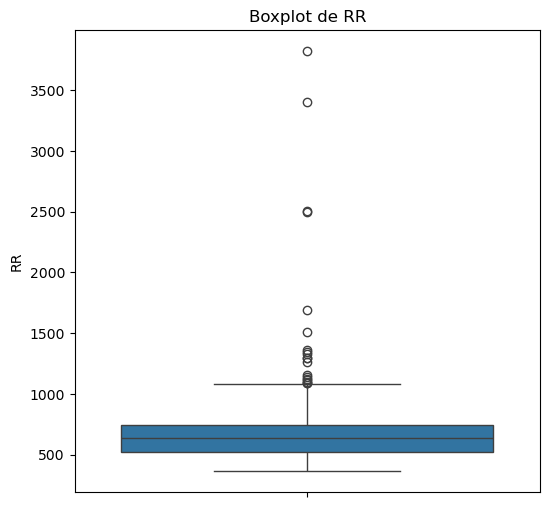

In [12]:
# Detección de valores atípicos en RR
def detectar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    return columna[(columna < umbral_inferior) | (columna > umbral_superior)]

valores_atipicos_rr = detectar_valores_atipicos(df['RR'])

print("Valores atípicos en RR con sus respectivos usuarios:")
valores_atipicos_con_usuarios = df[df['RR'].isin(valores_atipicos_rr)][['user', 'RR']]
print(valores_atipicos_con_usuarios)

# Visualización de valores atípicos en RR
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['RR'])
plt.title('Boxplot de RR')
plt.show()


In [13]:
# Filtra el DataFrame para eliminar los valores atípicos
df = df[~df['RR'].isin(valores_atipicos_rr)]

# Extracción de características

In [14]:
# Función para calcular características de HRV
def calculate_hrv_features(rr_intervals):
    # Convierte los intervalos RR a un arreglo de NumPy
    rr_intervals = rr_intervals.to_numpy()

    # Características del dominio del tiempo
    mean_rr = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))
    nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 50)
    pnn50 = (nn50 / len(rr_intervals)) * 100

    # Características del dominio de la frecuencia
    x = np.cumsum(rr_intervals) / 1000.0
    f = interp1d(x, rr_intervals, kind='cubic')
    fs = 4.0  # Nueva tasa de muestreo en Hz
    x_new = np.arange(x[0], x[-1], 1 / fs)
    rr_interpolated = f(x_new)

    frequencies, psd = welch(rr_interpolated, fs=fs, nperseg=256)

    # Define las bandas de frecuencia
    vlf_band = (0.003, 0.04)
    lf_band = (0.04, 0.15)
    hf_band = (0.15, 0.4)

    # Calcula la potencia en cada banda
    vlf_power = np.trapz(y=psd[(frequencies >= vlf_band[0]) & (frequencies <= vlf_band[1])], x=frequencies[(frequencies >= vlf_band[0]) & (frequencies <= vlf_band[1])])
    lf_power = np.trapz(y=psd[(frequencies >= lf_band[0]) & (frequencies <= lf_band[1])], x=frequencies[(frequencies >= lf_band[0]) & (frequencies <= lf_band[1])])
    hf_power = np.trapz(y=psd[(frequencies >= hf_band[0]) & (frequencies <= hf_band[1])], x=frequencies[(frequencies >= hf_band[0]) & (frequencies <= hf_band[1])])

    # Calcula la razón LF/HF
    lf_hf_ratio = lf_power / hf_power

    # Calcula estadísticas adicionales
    additional_stats = {
        'Max RR Interval': np.max(rr_intervals),
        'Min RR Interval': np.min(rr_intervals),
        'Skewness': pd.Series(rr_intervals).skew(),
        'Median RR Interval': np.median(rr_intervals),
        'Variance': np.var(rr_intervals),
        'MAD': np.mean(np.abs(rr_intervals - np.mean(rr_intervals)))
    }

    # Almacena las características calculadas en un diccionario
    features = {
        'Mean RR Interval': mean_rr,
        'SDNN': sdnn,
        'RMSSD': rmssd,
        'pNN50': pnn50,
        'VLF': vlf_power,
        'LF': lf_power,
        'HF': hf_power,
        'LF/HF Ratio': lf_hf_ratio,
        **additional_stats
    }

    return features

hrv_features_by_user = df.groupby('user')['RR'].apply(calculate_hrv_features).unstack().reset_index()
hrv_features_by_user

,user,Mean RR Interval,SDNN,RMSSD,pNN50,VLF,LF,HF,LF/HF Ratio,Max RR Interval,Min RR Interval,Skewness,Median RR Interval,Variance,MAD
0,cielo,509.798621,78.718149,76.283792,5.931034,473.108559,778.109076,2027.954422,0.383692,1082.0,422.0,2.788502,493.0,6196.547033,53.280049
1,cristina,453.761346,66.192978,9.243169,0.391236,188.564871,97.034166,55.925991,1.735046,737.0,364.0,1.274059,433.0,4381.510337,51.171499
2,david,702.666667,86.261084,19.478053,2.144250,730.010514,559.083963,134.695263,4.150732,901.0,544.0,-0.030633,714.0,7440.974659,73.630929
3,ignacio,678.211618,81.742415,29.430916,9.336100,776.831943,446.943069,431.134147,1.036668,875.0,536.0,0.234383,679.0,6681.822438,70.867220
4,isabel,693.238913,64.133836,17.966062,1.716738,171.713903,995.360194,118.517357,8.398434,914.0,558.0,0.495506,688.0,4113.148929,49.756439
5,jaime,795.858209,84.558127,35.960390,11.691542,1105.803332,2352.071537,338.367366,6.951236,997.0,529.0,-0.154507,804.5,7150.076910,69.843209
6,jorge,713.625974,59.919690,44.105490,18.701299,460.239405,851.060165,566.820983,1.501462,955.0,589.0,0.518534,704.0,3590.369195,48.766632
7,juan,804.834471,130.975279,61.053332,29.180887,1481.512607,2558.029442,1473.984998,1.735451,1083.0,530.0,0.021464,803.5,17154.523795,112.492609
8,katia,767.384956,123.422372,33.685417,11.946903,1835.286266,2046.272147,293.632249,6.968826,1037.0,521.0,-0.145350,782.5,15233.081898,102.823655
9,luis,708.263352,74.349324,33.327570,3.499079,446.555681,595.965837,251.674347,2.368004,974.0,475.0,-0.255807,718.0,5527.821990,60.724805


In [15]:
df = pd.merge(df, hrv_features_by_user, on='user')

print(df.head().to_markdown(index=False, numalign="left", stralign="left"))


| time_seconds   | RR   | hear rate file   | user    | sex   | VR experience   | heart/vertigo issue   | event   | fear level   | Mean RR Interval   | SDNN    | RMSSD   | pNN50   | VLF     | LF      | HF      | LF/HF Ratio   | Max RR Interval   | Min RR Interval   | Skewness   | Median RR Interval   | Variance   | MAD     |
|:---------------|:-----|:-----------------|:--------|:------|:----------------|:----------------------|:--------|:-------------|:-------------------|:--------|:--------|:--------|:--------|:--------|:--------|:--------------|:------------------|:------------------|:-----------|:---------------------|:-----------|:--------|
| 0              | 656  | ignacio.txt      | ignacio | 1     | 1               | 0                     | relax   | 0            | 678.212            | 81.7424 | 29.4309 | 9.3361  | 776.832 | 446.943 | 431.134 | 1.03667       | 875               | 536               | 0.234383   | 679                  | 6681.82    | 70.8672 |
| 1              | 631

In [16]:
df_clean = df.dropna()
df_clean = df_clean.drop(columns=["time_seconds", "RR", "hear rate file", "event", "fear level"]).drop_duplicates().reset_index(drop=True)

In [17]:
df_clean.to_csv("cleaned_data.csv", index=False)
df_clean

,user,sex,VR experience,heart/vertigo issue,Mean RR Interval,SDNN,RMSSD,pNN50,VLF,LF,HF,LF/HF Ratio,Max RR Interval,Min RR Interval,Skewness,Median RR Interval,Variance,MAD
0,ignacio,1,1,0,678.211618,81.742415,29.430916,9.336100,776.831943,446.943069,431.134147,1.036668,875.0,536.0,0.234383,679.0,6681.822438,70.867220
1,juan,1,1,1,804.834471,130.975279,61.053332,29.180887,1481.512607,2558.029442,1473.984998,1.735451,1083.0,530.0,0.021464,803.5,17154.523795,112.492609
2,david,1,1,0,702.666667,86.261084,19.478053,2.144250,730.010514,559.083963,134.695263,4.150732,901.0,544.0,-0.030633,714.0,7440.974659,73.630929
3,jorge,1,1,0,713.625974,59.919690,44.105490,18.701299,460.239405,851.060165,566.820983,1.501462,955.0,589.0,0.518534,704.0,3590.369195,48.766632
4,cristina,0,1,0,453.761346,66.192978,9.243169,0.391236,188.564871,97.034166,55.925991,1.735046,737.0,364.0,1.274059,433.0,4381.510337,51.171499
5,isabel,0,0,1,693.238913,64.133836,17.966062,1.716738,171.713903,995.360194,118.517357,8.398434,914.0,558.0,0.495506,688.0,4113.148929,49.756439
6,katia,0,1,0,767.384956,123.422372,33.685417,11.946903,1835.286266,2046.272147,293.632249,6.968826,1037.0,521.0,-0.145350,782.5,15233.081898,102.823655
7,cielo,0,0,1,509.798621,78.718149,76.283792,5.931034,473.108559,778.109076,2027.954422,0.383692,1082.0,422.0,2.788502,493.0,6196.547033,53.280049
8,mario,1,1,0,550.489583,49.113358,21.002129,2.083333,339.441476,905.331057,196.736348,4.601748,923.0,473.0,2.820717,544.0,2412.121915,32.709914
9,jaime,1,0,0,795.858209,84.558127,35.960390,11.691542,1105.803332,2352.071537,338.367366,6.951236,997.0,529.0,-0.154507,804.5,7150.076910,69.843209


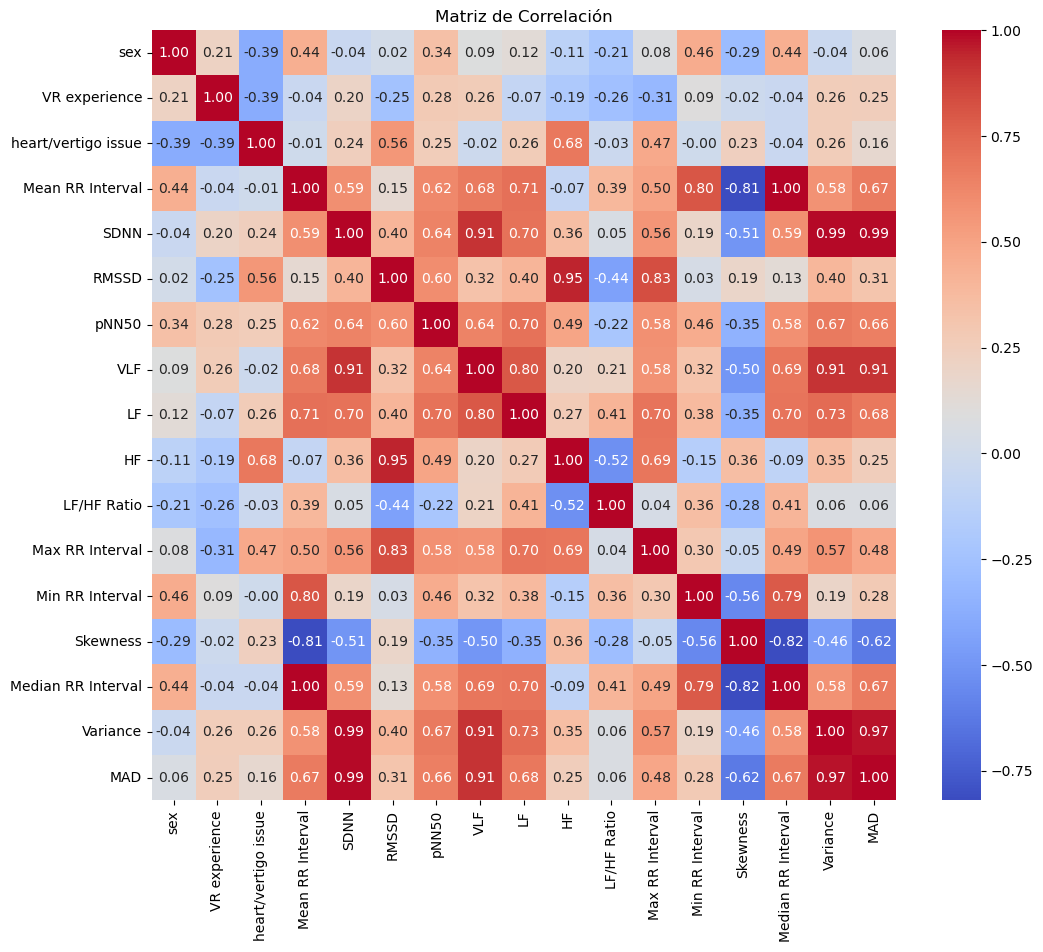

In [18]:
# Calculamos la matriz de correlación
correlation_matrix = df_clean.drop(columns=[ 'user']).corr()

# Configuramos el tamaño del gráfico
plt.figure(figsize=(12, 10))

# Creamos un mapa de calor de la matriz de correlación
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Mostramos el gráfico
plt.title('Matriz de Correlación')
plt.show()

In [19]:
X = df_clean.drop(columns=['VR experience', 'user'])
y = df_clean['VR experience']

In [20]:
# Inicializas SelectKBest con la función de puntuación f_classif
selector = SelectKBest(f_classif, k=5)

# Ajustas y transformas los datos para seleccionar las 5 características principales
X_selected = selector.fit_transform(X, y)

# Obtienes los índices de las características seleccionadas
selected_indices = selector.get_support(indices=True)

# Obtienes los nombres de las características seleccionadas
selected_features = X.columns[selected_indices]
selected_features = selected_features.to_list()

# Imprimes los nombres de las características seleccionadas
print("Características seleccionadas:", selected_features)


Características seleccionadas: ['heart/vertigo issue', 'pNN50', 'VLF', 'LF/HF Ratio', 'Max RR Interval']


In [21]:
X = df_clean[selected_features]
y = df_clean['VR experience']
groups = df_clean['user']

# Defines los modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# Inicializas el validador cruzado Leave-One-Group-Out
logo = LeaveOneGroupOut()

# Diccionario para almacenar la precisión promedio de cada modelo
average_accuracies = {}

# Realizas la validación cruzada Leave-One-Group-Out para cada modelo
for model_name, model in models.items():
    accuracies = []
    
    for train_index, test_index in logo.split(X, y, groups):
        # Divides los datos en conjuntos de entrenamiento y prueba
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Ajustas el modelo en los datos de entrenamiento
        model.fit(X_train, y_train)
        
        # Predices en los datos de prueba
        y_pred = model.predict(X_test)
        
        # Calculas la precisión para esta iteración
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)
    
    # Calculas la precisión promedio en todas las iteraciones
    average_accuracy = sum(accuracies) / len(accuracies)
    average_accuracies[model_name] = average_accuracy

# Imprimes la precisión promedio para cada modelo
for model_name, avg_accuracy in average_accuracies.items():
    print(f'{model_name}: Precisión Promedio = {avg_accuracy:.4f}')


Logistic Regression: Precisión Promedio = 0.5455
Support Vector Machine: Precisión Promedio = 0.6364
Decision Tree: Precisión Promedio = 0.2727
Random Forest: Precisión Promedio = 0.5455
K-Nearest Neighbors: Precisión Promedio = 0.1818
CatBoost: Precisión Promedio = 0.3636


No logre hacer funcionar Kubios en mi computadora, no me dejaba crear cuenta ni acceder